## Agentic RAG


Agentic RAG is an advanced evolution of Retrieval-Augmented Generation (RAG) where an AI system doesn’t just retrieve information and generate answers—it actively plans, decides, and takes actions like an “agent.”

In [165]:
import warnings

warnings.filterwarnings("ignore")

In [166]:
from typing import Annotated, Literal, Sequence, TypedDict
from langchainhub import Client
from langchain_core.messages import BaseMessage, HumanMessage
from langchain_core.output_parsers import StrOutputParser
from langchain_core.prompts import PromptTemplate
from pydantic import BaseModel, Field
from langgraph.graph.message import add_messages
from langgraph.prebuilt import tools_condition
from langchain_community.document_loaders import WebBaseLoader
from langchain_community.vectorstores import Chroma
from langchain_text_splitters import RecursiveCharacterTextSplitter
from langchain_core.tools.retriever import create_retriever_tool
from langgraph.graph import END, StateGraph, START
from langgraph.prebuilt import ToolNode

In [167]:
import os
from dotenv import load_dotenv
load_dotenv()
GOOGLE_API_KEY=os.getenv("GOOGLE_API_KEY")
TAVILY_API_KEY=os.getenv("TAVILY_API_KEY")
GROQ_API_KEY=os.getenv("GROQ_API_KEY")
LANGCHAIN_API_KEY=os.getenv("LANGCHAIN_API_KEY")
os.environ["GOOGLE_API_KEY"] = GOOGLE_API_KEY
os.environ["TAVILY_API_KEY"] = TAVILY_API_KEY
os.environ["GROQ_API_KEY"]= GROQ_API_KEY
os.environ["LANGCHAIN_API_KEY"] = LANGCHAIN_API_KEY
os.environ["LANGCHAIN_TRACING_V2"] = "true"
os.environ["LANGCHAIN_ENDPOINT"] = "https://api.smith.langchain.com"

In [168]:
# loading the embeddings model
from langchain_huggingface import HuggingFaceEmbeddings
from langchain_groq import ChatGroq

embeddings = HuggingFaceEmbeddings(
    model_name="sentence-transformers/all-MiniLM-L6-v2"
)

llm=ChatGroq(model="llama-3.1-8b-instant")

Loading weights: 100%|██████████| 103/103 [00:00<00:00, 21684.15it/s]


In [169]:
url= "https://lilianweng.github.io/posts/2023-06-23-agent/"

In [170]:
WebBaseLoader(url).load()

[Document(metadata={'source': 'https://lilianweng.github.io/posts/2023-06-23-agent/', 'title': "LLM Powered Autonomous Agents | Lil'Log", 'description': 'Building agents with LLM (large language model) as its core controller is a cool concept. Several proof-of-concepts demos, such as AutoGPT, GPT-Engineer and BabyAGI, serve as inspiring examples. The potentiality of LLM extends beyond generating well-written copies, stories, essays and programs; it can be framed as a powerful general problem solver.\nAgent System Overview\nIn a LLM-powered autonomous agent system, LLM functions as the agent’s brain, complemented by several key components:\n\nPlanning\n\nSubgoal and decomposition: The agent breaks down large tasks into smaller, manageable subgoals, enabling efficient handling of complex tasks.\nReflection and refinement: The agent can do self-criticism and self-reflection over past actions, learn from mistakes and refine them for future steps, thereby improving the quality of final resu

In [171]:
urls = [
    "https://lilianweng.github.io/posts/2023-06-23-agent/",
    "https://lilianweng.github.io/posts/2023-03-15-prompt-engineering/",
]

In [172]:
docs=[WebBaseLoader(url).load() for url in urls]

In [173]:
docs

[[Document(metadata={'source': 'https://lilianweng.github.io/posts/2023-06-23-agent/', 'title': "LLM Powered Autonomous Agents | Lil'Log", 'description': 'Building agents with LLM (large language model) as its core controller is a cool concept. Several proof-of-concepts demos, such as AutoGPT, GPT-Engineer and BabyAGI, serve as inspiring examples. The potentiality of LLM extends beyond generating well-written copies, stories, essays and programs; it can be framed as a powerful general problem solver.\nAgent System Overview\nIn a LLM-powered autonomous agent system, LLM functions as the agent’s brain, complemented by several key components:\n\nPlanning\n\nSubgoal and decomposition: The agent breaks down large tasks into smaller, manageable subgoals, enabling efficient handling of complex tasks.\nReflection and refinement: The agent can do self-criticism and self-reflection over past actions, learn from mistakes and refine them for future steps, thereby improving the quality of final res

In [174]:
docs_list=[item for sublist in docs for item in sublist]

In [175]:
## dividing the documents into chunks

text_splitter=RecursiveCharacterTextSplitter.from_tiktoken_encoder(chunk_size=100, chunk_overlap=25)


doc_splits=text_splitter.split_documents(docs_list)

In [176]:
doc_splits

[Document(metadata={'source': 'https://lilianweng.github.io/posts/2023-06-23-agent/', 'title': "LLM Powered Autonomous Agents | Lil'Log", 'description': 'Building agents with LLM (large language model) as its core controller is a cool concept. Several proof-of-concepts demos, such as AutoGPT, GPT-Engineer and BabyAGI, serve as inspiring examples. The potentiality of LLM extends beyond generating well-written copies, stories, essays and programs; it can be framed as a powerful general problem solver.\nAgent System Overview\nIn a LLM-powered autonomous agent system, LLM functions as the agent’s brain, complemented by several key components:\n\nPlanning\n\nSubgoal and decomposition: The agent breaks down large tasks into smaller, manageable subgoals, enabling efficient handling of complex tasks.\nReflection and refinement: The agent can do self-criticism and self-reflection over past actions, learn from mistakes and refine them for future steps, thereby improving the quality of final resu

In [177]:
## Add into vector Store

vectorstore=Chroma.from_documents(
    documents=doc_splits,
    collection_name="rag-chrome",
    embedding=embeddings
    
)

In [178]:
## making retriever

retriever=vectorstore.as_retriever()

In [179]:
retreiver_tool=create_retriever_tool(
    retriever,
    "retrieve_blog_posts",
    "Search and return information about Lilian Weng blog posts on LLM agents, prompt engineering, and adversarial attacks on LLMs.You are a specialized assistant. Use the 'retriever_tool' **only** when the query explicitly relates to LangChain blog data. For all other queries, respond directly without using any tool. For simple queries like 'hi', 'hello', or 'how are you', provide a normal response.",
    
)

In [180]:
tools=[retreiver_tool]

In [181]:
retrieve=ToolNode([retreiver_tool])

In [182]:
class AgentState(TypedDict):
    messages: Annotated[Sequence[BaseMessage], add_messages]

In [183]:
# ## ai assistant node

def ai_assistant(state:AgentState):
    print("---CALL AGENT---")
    messages=state["messages"]

    if len(messages)>1:
        last_message=messages[-1]
        question=last_message.content

        prompt=PromptTemplate(
        template="""You are a helpful assistant whatever question has been asked to find out that in the given question and answer.
                        Here is the question:{question}
                        """,
                        input_variables=["question"]
        )

        chain=prompt | llm

        response=chain.invoke({"question":question})

        return {"messages":[response]}
    else:
        llm_with_tools=llm.bind_tools(tools)
        response=llm_with_tools.invoke(messages)

        return {"messages":[response]}


# def ai_assistant(state: AgentState):
#     print("---CALL AGENT---")
#     messages = state["messages"]
#     llm_with_tools = llm.bind_tools(tools)   # always bind tools
#     response = llm_with_tools.invoke(messages)
#     return {"messages": [response]}

In [184]:
## grade class to check whether the answer is relevant or not

class grade(BaseModel):
    binary_score:str=Field(description="Relevance score 'yes' or 'no'")

In [185]:
## Grade documents node 

def grade_documents(state:AgentState)->Literal["Output_Generator","Query_Rewriter"]:
    llm_with_structured_output=llm.with_structured_output(grade)

    prompt=PromptTemplate(
        template="""You are a grader deciding if a document is relevant to a user’s question.
                    Here is the document: {context}
                    Here is the user’s question: {question}
                    If the document talks about or contains information related to the user’s question, mark it as relevant. 
                    Give a 'yes' or 'no' answer to show if the document is relevant to the question.""",
                    input_variables=["context", "question"]
        )
    
    chain=prompt | llm_with_structured_output

    messages = state["messages"]
    last_message = messages[-1]
    question = messages[0].content
    docs = last_message.content
    scored_result = chain.invoke({"question": question, "context": docs})

    score = scored_result.binary_score

    if score=="yes":
        print("---DECISION: DOCS RELEVANT---")
        return "generator"
    else:
        print("---DECISION: DOCS NOT RELEVANT---")
        return "rewriter" 

In [186]:
from langchain_core.messages import ToolMessage
from langchain_core.prompts import ChatPromptTemplate

## generate the final ans

def generate(state: AgentState):
    print("---GENERATE---")

    messages = state["messages"]
    question = messages[0].content

    # Find the last ToolMessage which contains retrieved docs
    docs = ""
    for msg in reversed(messages):
        if isinstance(msg, ToolMessage):
            docs = msg.content
            break

    # client=Client()

    # prompt = client.pull("rlm/rag-prompt")  # use hub directly, not Client().pull()

    # Define prompt locally — no hub needed
    rag_prompt = ChatPromptTemplate.from_messages([
        ("system", """You are an assistant for question-answering tasks. 
    Use the following retrieved context to answer the question. 
    If you don't know the answer, just say you don't know.

    Context:
    {context}"""),
        ("human", "{question}")
    ])

    rag_chain = rag_prompt | llm

    response = rag_chain.invoke({"context": docs, "question": question})

    return {"messages": [response]}

In [187]:
from langchain_core.messages import  HumanMessage

## Rewrite Node (convert the query into a meaningful query)

def rewrite(state:AgentState):
    print("---TRANSFORM QUERY---")
    messages = state["messages"]
    question = messages[0].content
    
    message = [HumanMessage(content=f"""Look at the input and try to reason about the underlying semantic intent or meaning. 
                    Here is the initial question: {question} 
                    Formulate an improved question: """)
       ]
    response = llm.invoke(message)
    return {"messages": [response]}

In [188]:
workflow=StateGraph(AgentState)

In [189]:
## making workflow

workflow.add_node("My_Ai_Assistant",ai_assistant)
workflow.add_node("Vector_Retriever",retrieve)
workflow.add_node("Output_Generator",generate)
workflow.add_node("Query_Rewriter",rewrite)

In [190]:
workflow.add_edge(START,"My_Ai_Assistant")
workflow.add_conditional_edges("My_Ai_Assistant",tools_condition,{
    "tools":"Vector_Retriever",
    END:END
})
workflow.add_conditional_edges("Vector_Retriever",
                            grade_documents,
                            {"generator": "Output_Generator",
                            "rewriter": "Query_Rewriter"
                            }
                            )
workflow.add_edge("Output_Generator", END)
workflow.add_edge("Query_Rewriter", "My_Ai_Assistant")


In [191]:

app=workflow.compile()

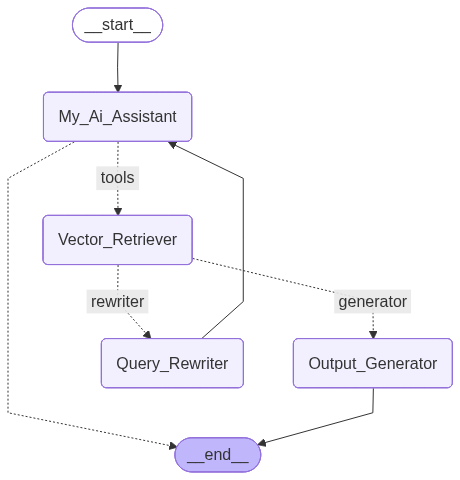

In [192]:
from IPython.display import Image, display

try:
    display(Image(app.get_graph(xray=True).draw_mermaid_png()))
except Exception:
    # This requires some extra dependencies and is optional
    pass

In [193]:
app.invoke({"messages":["What is a Autonomous Agent?"]})

---CALL AGENT---


{'messages': [HumanMessage(content='What is a Autonomous Agent?', additional_kwargs={}, response_metadata={}, id='dfb9fde8-98df-4e56-bae5-eee9c08fda5d'),
  AIMessage(content='An autonomous agent is a software system that can perform tasks or make decisions without human intervention. It can operate independently, using its own knowledge, logic, and algorithms to achieve its objectives. Autonomous agents can be found in various fields, including robotics, artificial intelligence, and expert systems.\n\nIn the context of artificial intelligence, autonomous agents are designed to interact with their environment and make decisions based on sensors, data, and algorithms. They can learn from their experiences, adapt to new situations, and improve their performance over time.\n\nSome common characteristics of autonomous agents include:\n\n1. **Autonomy**: They can operate independently, making decisions without human input.\n2. **Reactivity**: They can respond to changes in their environment.

In [194]:
app.invoke({"messages": [HumanMessage(content="What is a Autonomous Agent?")]})

---CALL AGENT---


{'messages': [HumanMessage(content='What is a Autonomous Agent?', additional_kwargs={}, response_metadata={}, id='32d8d8b7-2eb8-4271-b318-3471d6954af9'),
  AIMessage(content='An autonomous agent is a software system that is capable of performing tasks independently, without direct human intervention. It is a self-contained entity that can perceive its environment, make decisions, and take actions based on those decisions. Autonomous agents can be found in various applications, such as robotics, artificial intelligence, and the Internet of Things (IoT).\n\nAutonomous agents typically have the following characteristics:\n\n1. **Autonomy**: They can operate independently, without direct human control.\n2. **Reactivity**: They can respond to changes in their environment.\n3. **Proactivity**: They can take initiative and make decisions based on their goals and objectives.\n4. **Social ability**: They can interact with other agents, humans, or the environment.\n5. **Learning ability**: They 

In [201]:

app.invoke({"messages":[HumanMessage(content="what is a prompt engineering explain me in terms of agents and langchain?")]})

---CALL AGENT---
---DECISION: DOCS RELEVANT---
---GENERATE---


{'messages': [HumanMessage(content='what is a prompt engineering explain me in terms of agents and langchain?', additional_kwargs={}, response_metadata={}, id='bb9b8e05-d32a-4227-8f40-75eb328e0f38'),
  AIMessage(content='', additional_kwargs={'tool_calls': [{'id': 'fg8p8vxxq', 'function': {'arguments': '{"query":"LangChain blog prompt engineering and agents"}', 'name': 'retrieve_blog_posts'}, 'type': 'function'}]}, response_metadata={'token_usage': {'completion_tokens': 22, 'prompt_tokens': 401, 'total_tokens': 423, 'completion_time': 0.043880866, 'completion_tokens_details': None, 'prompt_time': 0.043549463, 'prompt_tokens_details': None, 'queue_time': 0.051530311, 'total_time': 0.087430329}, 'model_name': 'llama-3.1-8b-instant', 'system_fingerprint': 'fp_4387d3edbb', 'service_tier': 'on_demand', 'finish_reason': 'tool_calls', 'logprobs': None, 'model_provider': 'groq'}, id='lc_run--019e014f-2ab5-71b0-ada8-1779f455b941-0', tool_calls=[{'name': 'retrieve_blog_posts', 'args': {'query': 

In [203]:

app.invoke({"messages":[HumanMessage(content="what is the capital of INDIA")]})

---CALL AGENT---


{'messages': [HumanMessage(content='what is the capital of INDIA', additional_kwargs={}, response_metadata={}, id='842f2ad6-e47c-44ce-a75f-98e3902b6e62'),
  AIMessage(content='New Delhi is the capital of India.', additional_kwargs={}, response_metadata={'token_usage': {'completion_tokens': 9, 'prompt_tokens': 393, 'total_tokens': 402, 'completion_time': 0.016153874, 'completion_tokens_details': None, 'prompt_time': 0.026944108, 'prompt_tokens_details': None, 'queue_time': 0.055966891, 'total_time': 0.043097982}, 'model_name': 'llama-3.1-8b-instant', 'system_fingerprint': 'fp_4387d3edbb', 'service_tier': 'on_demand', 'finish_reason': 'stop', 'logprobs': None, 'model_provider': 'groq'}, id='lc_run--019e014f-6e95-76e0-b3e1-ae3d7683f421-0', tool_calls=[], invalid_tool_calls=[], usage_metadata={'input_tokens': 393, 'output_tokens': 9, 'total_tokens': 402})]}